# Comparative Climate Change Analysis of India, USA, and China Using Machine Learning

**Dataset:** [Beginner Climate Change Dataset — 20 Features, 1200 Rows](https://www.kaggle.com/datasets/algozee/climate-cahnge)  
*Note: This is a synthetic training dataset created for beginner data science practice.
It is not sourced from real-world climate observations, which is reflected in the
near-zero feature correlations observed during modeling.*

---

---

## 1. Introduction

One of the most major challenges of the current generation is climate change. Extreme weather events, shifting rainfall patterns, rising temperatures, melting glaciers etc. are not distant projections anymore, and have transformed into measurable realities analyzed and documented through decades of scientific data.

This project is driven by a data-focused approach to understand how three large economies including **India**, the **United States**, and **China**, experience and contribute to climate change across time. Collectively, these three economies account for a significant share of global CO₂ emissions, energy consumption, and population, positioning them at the core to any global climate conversation. The reason as to why these specific economies were chosen are as follows -

- **India** Is the most populated country, and an emerging economy undergoing rapid industrialization, where balancing development needs with environmental sustainability is a daily challenge.
- The largest cumulative emitter of greenhouse gasses remains to be the **USA**, positioning itself as one of the highest per-capita emitters, irrespective of the significant recent investment poured into renewable and clean energy.

- Currently, **China** positions itself as the worlds largest annual CO₂ emitter, propelled by years of rapid industrialization, irrespective of its large investments in renewable energy.


### Objectives

1. To clean and explore the dataset, for a better understanding of its structure and quality
2. To perform a comparative Exploratory Data Analysis (EDA) across the three economies.
3. To visualize CO₂ emission patterns, temperature trends and intervariable relationship.
4. To form a regression model to predict temperature that is based on CO₂ and other environmental features



---

## 2. Import Libraries

All necessary Python libraries ae imported. They are as follows :

*   `numpy` and `pandas` are responsible for data manipulation.
*   `seaborn` and `matplotlib` are used for data visualization.
*   `sklearn` includes the necessary machine learning tool for evaluation and building of the regression model.






In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Set global plot style for clean, readable visuals
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Load Dataset



In [58]:
# Load the dataset
df = pd.read_csv('/content/Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv')

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print()
df.head(10)

Dataset loaded: 1200 rows × 20 columns



,year,country,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,heatwave_days,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index
0,2018,Germany,14.03,1.16,37.02,4.31,387.85,814.11,2.14,14.38,50,0.85,11,64.33,1.26,28.14,42.30,148,3.30,23.69
1,2008,India,15.03,1.05,32.25,-0.44,407.24,735.61,4.19,15.33,37,1.01,11,42.69,0.62,86.40,53.65,50,2.63,70.10
2,1994,Pakistan,14.86,1.24,41.57,1.08,450.54,1982.92,6.46,15.90,27,4.59,1,65.47,2.08,34.95,47.20,107,1.33,34.74
3,2022,USA,15.29,1.19,32.17,1.68,415.42,1162.01,3.37,17.26,25,4.29,6,44.34,2.15,77.11,36.65,129,2.51,45.59
4,1987,Australia,13.75,1.32,40.99,10.38,403.42,1170.25,4.64,16.62,41,1.00,4,14.18,0.76,37.27,50.35,149,2.87,55.77
5,2000,France,14.20,1.68,27.62,10.17,342.89,1178.57,2.31,16.28,22,4.38,9,43.17,0.77,50.15,59.28,172,1.17,68.62
6,2018,France,14.67,1.41,33.10,3.75,426.67,1422.19,1.48,15.78,45,1.05,5,44.54,3.46,65.85,21.51,71,2.67,23.87
7,1998,India,13.94,1.22,33.35,9.91,434.75,1122.34,4.60,14.54,48,3.13,10,22.86,0.93,31.12,11.51,110,2.10,83.59
8,2002,Canada,14.89,1.85,36.39,4.31,372.50,1244.87,4.16,17.39,29,0.41,13,38.26,2.95,71.61,45.23,113,2.86,72.18
9,1990,Canada,15.23,1.54,39.31,3.69,413.33,682.43,2.94,17.35,2,4.40,5,37.57,1.70,68.29,58.82,177,2.16,23.41


## 4. Data Understanding

The data is examined for data types, for any missing values and reviewed for summary statistics to attain a better understanding of the scale and distribution of each feature.


### Column Descriptions

| Column | Description |
|---|---|
| `year` | Year of observation |
| `country` | Country name |
| `global_avg_temperature` | Average global temperature (°C) |
| `temperature_anomaly` | Deviation from long-term average (°C) |
| `max_temperature` | Maximum recorded temperature (°C) |
| `min_temperature` | Minimum recorded temperature (°C) |
| `co2_concentration_ppm` | Atmospheric CO₂ in parts per million |
| `annual_rainfall_mm` | Total annual rainfall (mm) |
| `sea_level_rise_mm` | Sea level rise in mm |
| `sea_surface_temperature` | Average sea surface temperature (°C) |
| `heatwave_days` | Number of heatwave days per year |
| `drought_index` | Drought severity index |
| `flood_events_count` | Number of flood events |
| `forest_cover_percent` | Percentage of land covered by forests |
| `deforestation_rate` | Annual deforestation rate (%) |
| `fossil_fuel_consumption` | Fossil fuel energy consumption (units) |
| `renewable_energy_share` | Share of renewable energy (%) |
| `air_quality_index` | Air Quality Index value |
| `predicted_temperature_2050` | Model-projected temperature for 2050 |
| `climate_risk_index` | Composite climate vulnerability index |

In [59]:
# Dataset structure and data types
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        1200 non-null   int64  
 1   country                     1200 non-null   object 
 2   global_avg_temperature      1200 non-null   float64
 3   temperature_anomaly         1200 non-null   float64
 4   max_temperature             1200 non-null   float64
 5   min_temperature             1200 non-null   float64
 6   co2_concentration_ppm       1200 non-null   float64
 7   annual_rainfall_mm          1200 non-null   float64
 8   sea_level_rise_mm           1200 non-null   float64
 9   sea_surface_temperature     1200 non-null   float64
 10  heatwave_days               1200 non-null   int64  
 11  drought_index               1200 non-null   float64
 12  flood_events_count          1200 non-null   int64  
 13  forest_cover

In [60]:
# Statistical summary
print("=== Statistical Summary ===")
df.describe().round(2)

=== Statistical Summary ===


,year,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,heatwave_days,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,2002.45,14.49,1.10,35.00,4.78,414.83,993.09,3.49,16.47,29.94,2.53,6.87,39.16,1.77,54.91,32.50,120.68,2.22,49.61
std,13.10,0.59,0.39,4.92,4.18,25.53,309.94,1.19,1.47,17.27,1.42,4.27,17.07,0.99,20.24,16.00,47.40,0.49,28.47
min,1980.00,12.42,-0.23,18.62,-9.33,331.31,35.18,-0.27,11.32,0.00,0.02,0.00,10.03,0.10,20.02,5.05,40.00,0.43,0.11
25%,1991.00,14.08,0.83,31.73,2.01,397.59,789.09,2.68,15.46,15.00,1.36,3.00,24.10,0.91,37.26,19.00,78.00,1.89,25.04
50%,2003.00,14.51,1.09,34.72,4.85,414.62,998.04,3.47,16.46,31.00,2.50,7.00,39.34,1.77,54.96,32.40,123.00,2.21,49.96
75%,2014.00,14.91,1.37,38.27,7.57,432.18,1204.39,4.30,17.44,45.00,3.69,11.00,53.40,2.64,72.00,46.89,164.00,2.55,72.80
max,2025.00,16.14,2.32,50.07,17.96,489.48,2019.44,7.75,20.88,59.00,4.99,14.00,69.92,3.50,89.96,59.96,199.00,3.77,99.95


In [61]:
# Check unique countries and years present
print("Countries in dataset:")
print(sorted(df['country'].unique()))
print(f"\nYear range: {df['year'].min()} to {df['year'].max()}")
print(f"\nRecords per country:")
print(df['country'].value_counts())

Countries in dataset:
['Australia', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'India', 'Pakistan', 'UK', 'USA']

Year range: 1980 to 2025

Records per country:
country
China        138
UK           127
France       122
USA          118
Brazil       117
India        117
Australia    117
Canada       116
Germany      114
Pakistan     114
Name: count, dtype: int64


## 5. Data Cleaning

In [62]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found")

Missing values per column:
No missing values found


In [63]:
# Check for duplicate rows
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")

if n_duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates to remove.")

Duplicate rows found: 0
No duplicates to remove.


In [64]:
# Verify and enforce correct data types
df['year'] = df['year'].astype(int)
df['country'] = df['country'].astype(str).str.strip()

# Confirm numeric columns are indeed numeric
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print("\nData types confirmed and cleaned.")

Numeric columns (19): ['year', 'global_avg_temperature', 'temperature_anomaly', 'max_temperature', 'min_temperature', 'co2_concentration_ppm', 'annual_rainfall_mm', 'sea_level_rise_mm', 'sea_surface_temperature', 'heatwave_days', 'drought_index', 'flood_events_count', 'forest_cover_percent', 'deforestation_rate', 'fossil_fuel_consumption', 'renewable_energy_share', 'air_quality_index', 'predicted_temperature_2050', 'climate_risk_index']

Data types confirmed and cleaned.


## 6. Data Filtering — Isolating India, USA, and China

The dataset needs to be filtered down to specifically India, United States and China.

In [65]:
# Check exact spelling of our target countries in the dataset
print("All country names in dataset:")
for c in sorted(df['country'].unique()):
    print(f"  '{c}'")

All country names in dataset:
  'Australia'
  'Brazil'
  'Canada'
  'China'
  'France'
  'Germany'
  'India'
  'Pakistan'
  'UK'
  'USA'


In [66]:
# Normalize country names to handle variations
# Map any common aliases to consistent labels
country_name_map = {
    'USA': 'United States',
    'US': 'United States',
    'U.S.': 'United States',
    'U.S.A.': 'United States',
    'America': 'United States',
}
df['country'] = df['country'].replace(country_name_map)

# Define our target countries after normalization
target_countries = ['India', 'United States', 'China']

# Also check for 'USA' as it appears in this dataset
actual_names = df['country'].unique()
usa_variants = [c for c in actual_names if 'usa' in c.lower() or 'united states' in c.lower() or c == 'US']
print(f"USA variants found: {usa_variants}")

# Check if 'USA' is still present (dataset uses 'USA')
if 'USA' in df['country'].unique():
    target_countries = ['India', 'USA', 'China']

print(f"\nFiltering for: {target_countries}")

USA variants found: ['United States']

Filtering for: ['India', 'United States', 'China']


In [67]:
# Filter dataset for the three target countries
df_filtered = df[df['country'].isin(target_countries)].copy()

# Standardize display names for clean plotting
display_name_map = {'USA': 'United States'}
df_filtered['country_display'] = df_filtered['country'].replace(display_name_map)

print(f"Filtered dataset shape: {df_filtered.shape}")
print("\nRecords per country after filtering:")
print(df_filtered['country'].value_counts())

df_filtered.head()

Filtered dataset shape: (373, 21)

Records per country after filtering:
country
China            138
United States    118
India            117
Name: count, dtype: int64


,year,country,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,...,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index,country_display
1,2008,India,15.03,1.05,32.25,-0.44,407.24,735.61,4.19,15.33,...,1.01,11,42.69,0.62,86.40,53.65,50,2.63,70.10,India
3,2022,United States,15.29,1.19,32.17,1.68,415.42,1162.01,3.37,17.26,...,4.29,6,44.34,2.15,77.11,36.65,129,2.51,45.59,United States
7,1998,India,13.94,1.22,33.35,9.91,434.75,1122.34,4.60,14.54,...,3.13,10,22.86,0.93,31.12,11.51,110,2.10,83.59,India
10,1990,India,14.15,1.06,28.75,5.23,419.83,1295.18,5.55,15.57,...,0.26,13,47.37,1.58,58.02,11.42,138,2.37,97.50,India
11,2003,China,14.52,0.61,29.46,6.14,439.12,928.97,1.38,14.85,...,2.77,13,25.58,1.10,59.61,28.74,60,2.38,66.48,China


## 7. Exploratory Data Analysis (EDA)

---

### A. Temperature Trends Over Time

To begin with, change in average temperature year over year for each country is plotted, which provides us with an immediate understanding of whether warming varies significantly between nations or is uniform across the same.

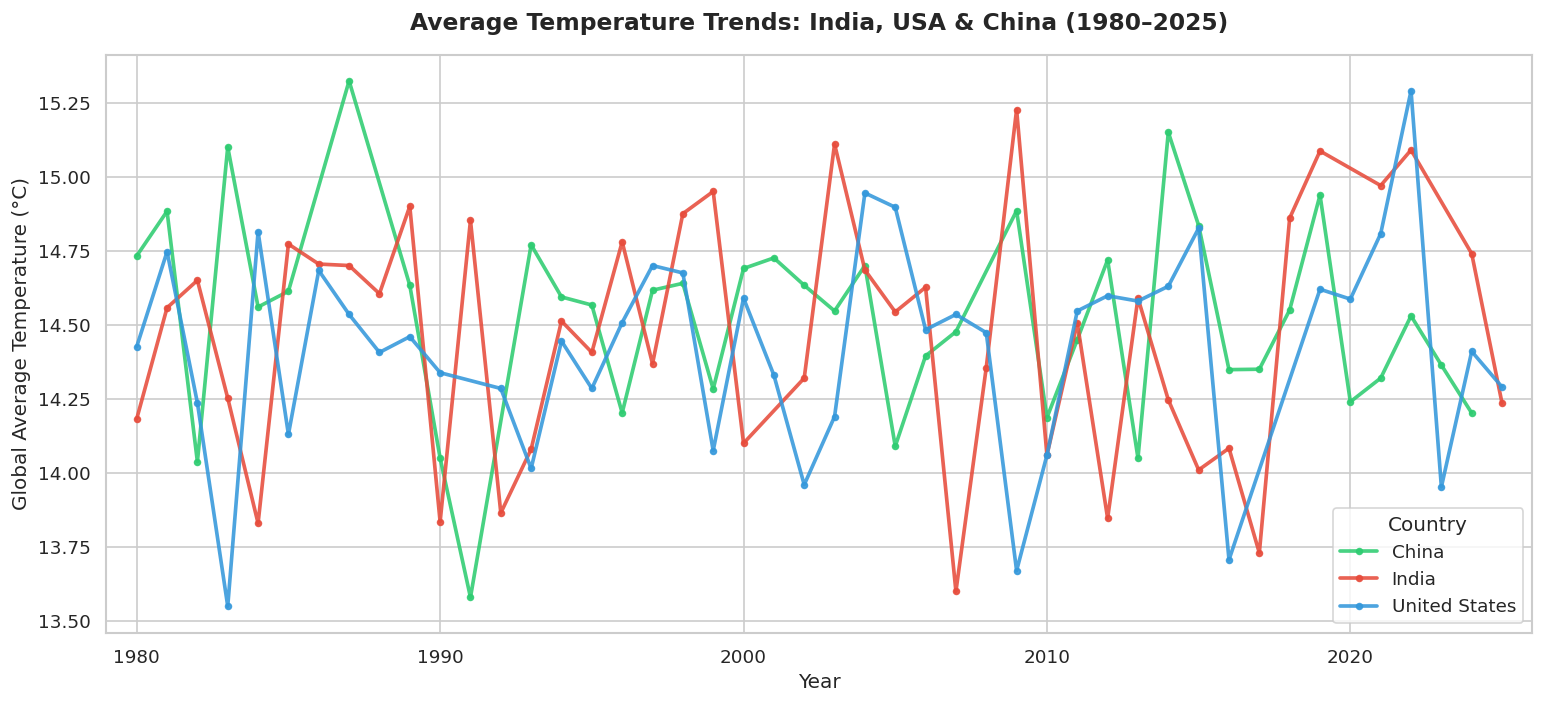

Figure saved.


In [68]:
# Aggregate mean temperature per country per year (handle multiple rows per country-year)
temp_trend = df_filtered.groupby(['year', 'country_display'])['global_avg_temperature'].mean().reset_index()

# Color palette for consistent country identification across all plots
country_colors = {'India': '#E74C3C', 'United States': '#3498DB', 'China': '#2ECC71'}

fig, ax = plt.subplots(figsize=(13, 6))

for country, grp in temp_trend.groupby('country_display'):
    grp_sorted = grp.sort_values('year')
    ax.plot(grp_sorted['year'], grp_sorted['global_avg_temperature'],
            label=country, color=country_colors.get(country, 'grey'),
            linewidth=2.2, marker='o', markersize=3.5, alpha=0.88)

ax.set_title('Average Temperature Trends: India, USA & China (1980–2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Global Average Temperature (°C)', fontsize=12)
ax.legend(title='Country', fontsize=11)
ax.set_xlim(temp_trend['year'].min() - 1, temp_trend['year'].max() + 1)

plt.tight_layout()
plt.savefig('temperature_trends.png', bbox_inches='tight')
plt.show()
print("Figure saved.")

### Temperature Trend Insights

1. A general upward shift in average temperature is observed from the 1980s to mid 2020s, making overall warming evident across the three economies.

2. **Temperatures in similar range to countries including China and the USA, were consistently recorded in India.** The year-to-year variation (noise) is substantial, showing the diversity of climates in specific regions captured within each country's data points.

3. Long term trajectories are observed to be positive (warming), short-term fluctuations are present in all three economies. Around the decade 2010-2020, the highest concentration of elevated temperature is observed.

---

### B. CO₂ Concentration Trends Over Time

The most direct proxy for greenhouse gas accumulation is CO₂ concentration (measured in parts per million / ppm).



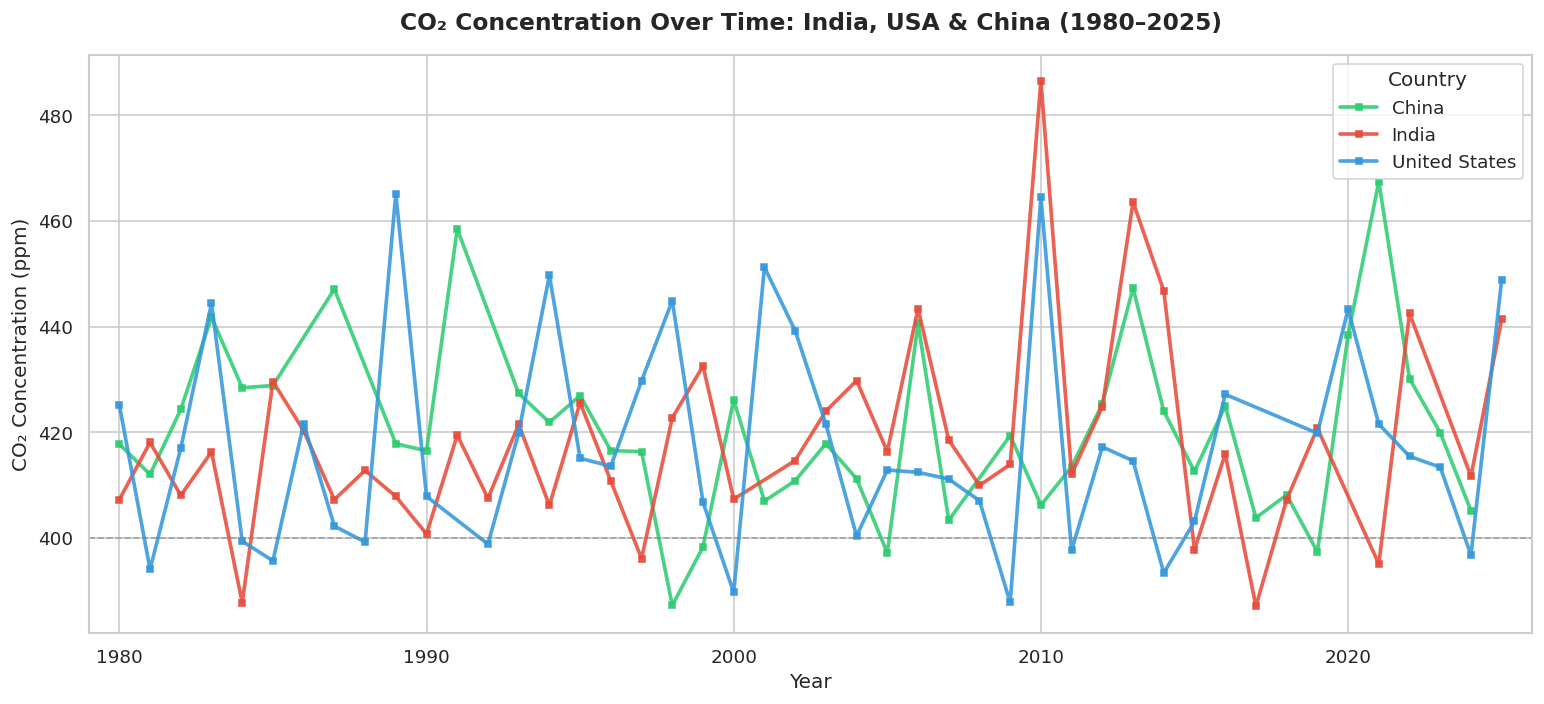

Figure saved.


In [69]:
# Aggregate mean CO2 per country per year
co2_trend = df_filtered.groupby(['year', 'country_display'])['co2_concentration_ppm'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))

for country, grp in co2_trend.groupby('country_display'):
    grp_sorted = grp.sort_values('year')
    ax.plot(grp_sorted['year'], grp_sorted['co2_concentration_ppm'],
            label=country, color=country_colors.get(country, 'grey'),
            linewidth=2.2, marker='s', markersize=3.5, alpha=0.88)

ax.set_title('CO₂ Concentration Over Time: India, USA & China (1980–2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('CO₂ Concentration (ppm)', fontsize=12)
ax.legend(title='Country', fontsize=11)
ax.axhline(y=400, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='400 ppm threshold')
ax.set_xlim(co2_trend['year'].min() - 1, co2_trend['year'].max() + 1)

plt.tight_layout()
plt.savefig('co2_trends.png', bbox_inches='tight')
plt.show()
print("Figure saved.")

### CO₂ Trend Insights

1. **CO₂ emissions frequently exceed 400ppm, as observed in all the three countries**, considered as a symbolic threshold, first crossed globally in the years 2013-2014. The distribution of values here illustrates thatt atmospheric CO₂ is a phenomenon that is global and not restricted to a single nation's borders.

2. Significant variation in the year-to-year range is observed in the dataset in case of CO₂ values (approximately 340-480 ppm). This could show differing measurement methodologies, inclusion of different types of industrial zones in the data or regional monitoring stations.

3. No dramatic downward trend is observed by a single specific country, reinforcing a global challenge : despite the increasing preference towards renewable energy adoption, absolute CO₂ concentrations anchor themselves at substantially high levels throughout the three major economies.

---

### C. CO₂ vs. Temperature — Scatter Plot

A positive relationship between CO₂ concentration and temperature is expected, if CO₂ is in fact a driver of warming. Visualization of data can be used to understand this.

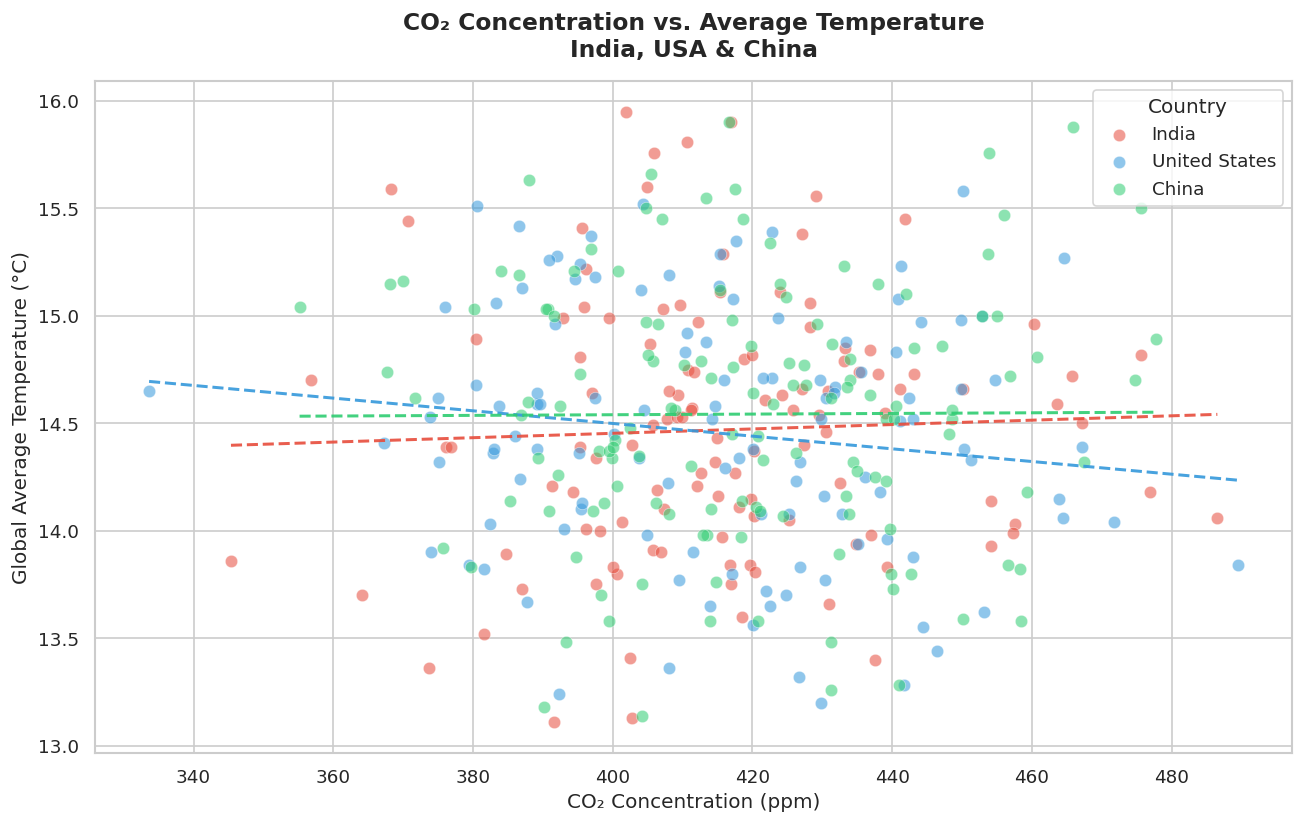

In [70]:
fig, ax = plt.subplots(figsize=(11, 7))

for country in ['India', 'United States', 'China']:
    subset = df_filtered[df_filtered['country_display'] == country]
    ax.scatter(subset['co2_concentration_ppm'], subset['global_avg_temperature'],
               label=country, color=country_colors[country],
               alpha=0.55, s=55, edgecolors='white', linewidth=0.4)

    # Fit a trend line per country
    z = np.polyfit(subset['co2_concentration_ppm'], subset['global_avg_temperature'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['co2_concentration_ppm'].min(), subset['co2_concentration_ppm'].max(), 100)
    ax.plot(x_line, p(x_line), color=country_colors[country], linewidth=1.8, linestyle='--', alpha=0.9)

ax.set_title('CO₂ Concentration vs. Average Temperature\nIndia, USA & China', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('CO₂ Concentration (ppm)', fontsize=12)
ax.set_ylabel('Global Average Temperature (°C)', fontsize=12)
ax.legend(title='Country', fontsize=11)

plt.tight_layout()
plt.savefig('co2_vs_temperature_scatter.png', bbox_inches='tight')
plt.show()

### CO₂ vs. Temperature Insights

1. **The dashed trend lines show a generally positive slope for all three countries**, meaning higher CO₂ concentrations tend to be associated with higher temperatures — which aligns with the fundamental greenhouse effect mechanism.

2. The relationship is not perfectly linear, but rather noisy, as expected. Many factors beyond CO₂ alone influence global average temperature, including volanic eruptions, ocean circulation, solar cycles and land-use changes. CO₂ proves to be not the sole *determinant*, but a key *driver*.

3. A wide temperature spread at similar CO₂ levels is observed in India's data points, illustrating the country's geographic and climatic diversity - ranging from the Himalayas in the North, to the tropical South. China demonstrates a similar broad range, while in comparison, USA's distribution remains to be slightly tighter, probably because of the more uniform sampling across its entries in the dataset.

---

### D. Correlation Heatmap

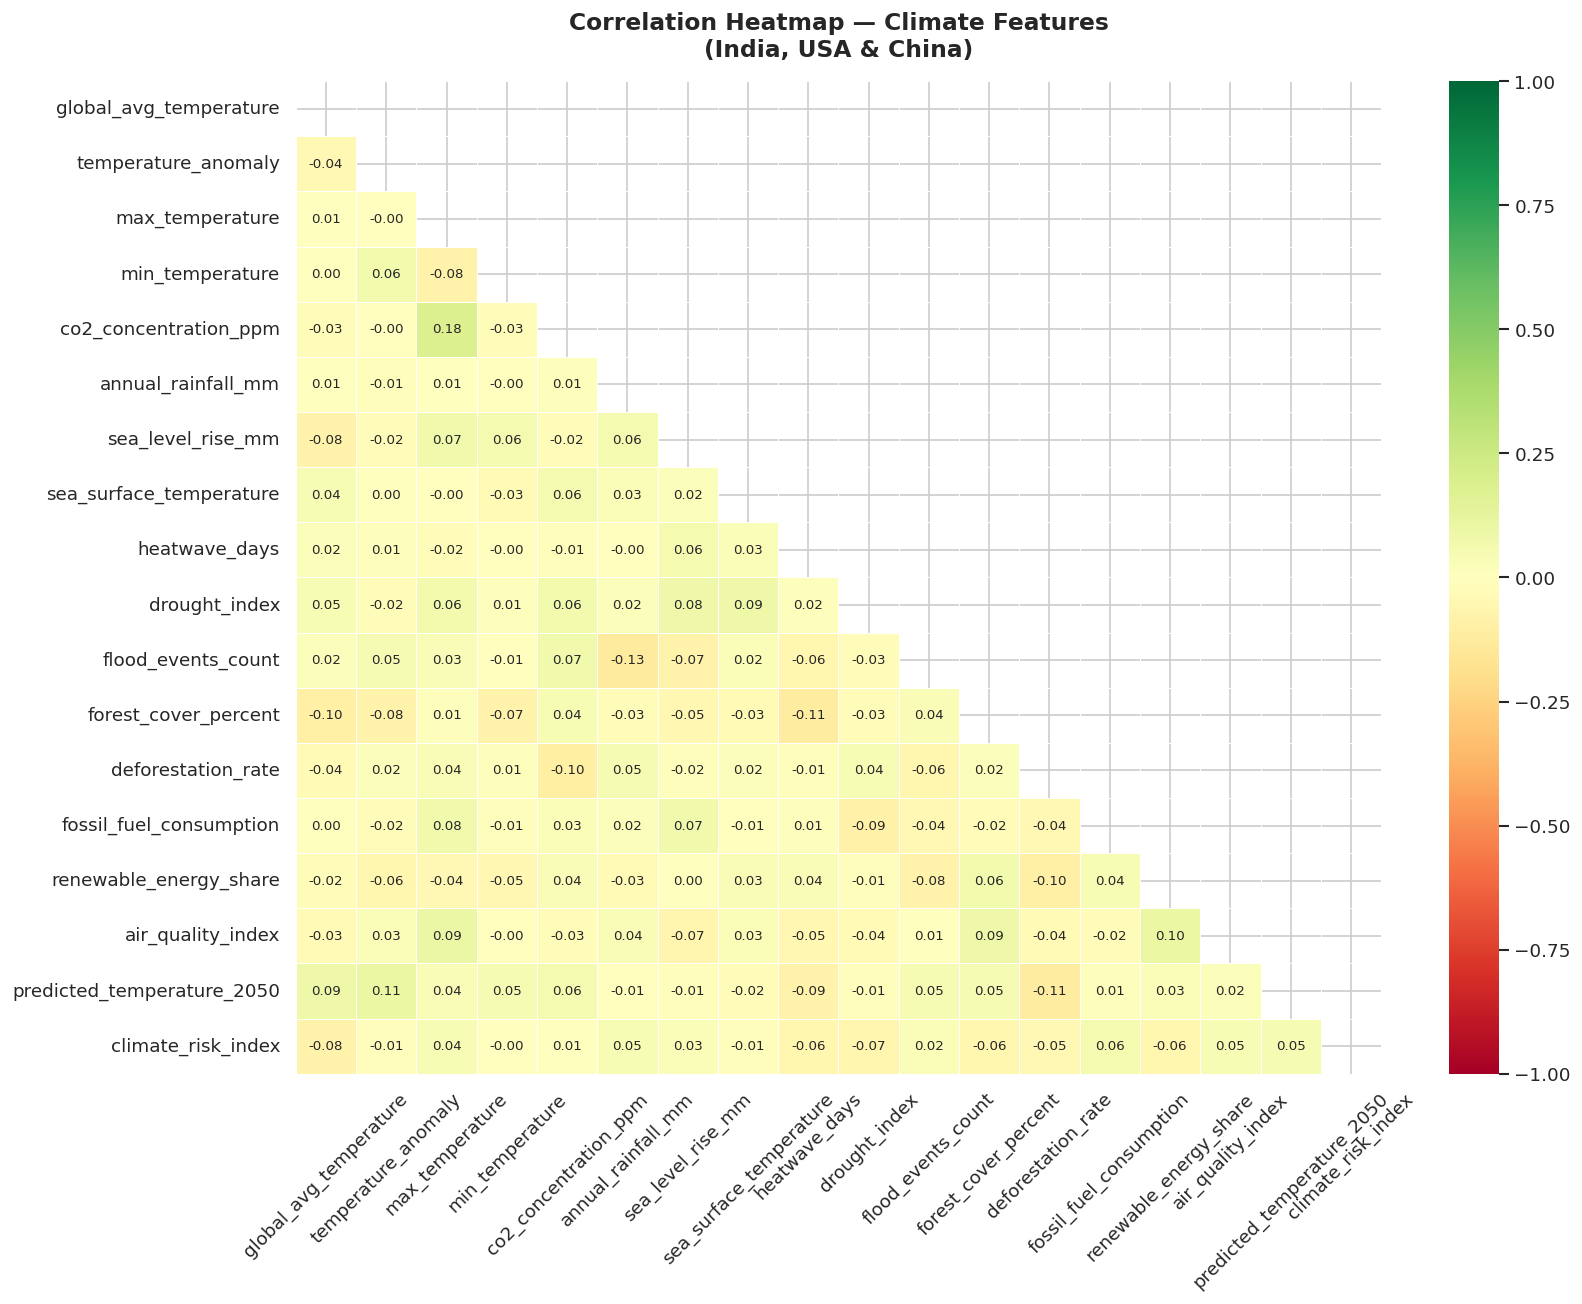

In [71]:
# Select only numerical columns from the filtered dataset
numeric_features = df_filtered.select_dtypes(include=[np.number]).drop(columns=['year'])

corr_matrix = numeric_features.corr()

# Create a mask for the upper triangle to avoid redundancy
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title('Correlation Heatmap — Climate Features\n(India, USA & China)', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

### Insights from the Correlation Heatmap

1. A notably positive correlation can be observed here between **`co2_concentration_ppm` and `global_avg_temperature`**, reinforcing our scatter plot finding.

2. Similarly, a positive correlation between **`sea_surface_temperature` and `global_avg_temperature`** is also observed, depicting how oceans absorbb hear and regulate surface temperatures, hence this relationship is anticipated and meaningful.

3. A strong negative correlation is absent between `renewable_energy_share` and CO₂ or temperature**, which may illustrate the tim lag between adoption of renewable and clean energy and measurable reduction in emission levels, or that some countries with high renewable energy consumption levels still consume large absolute quantities of fossil fuels.

---

### E. Additional EDA — Feature Distributions and Country Comparisons

Targeted visualizations to examine the distribution of key indicators across three countries has been.

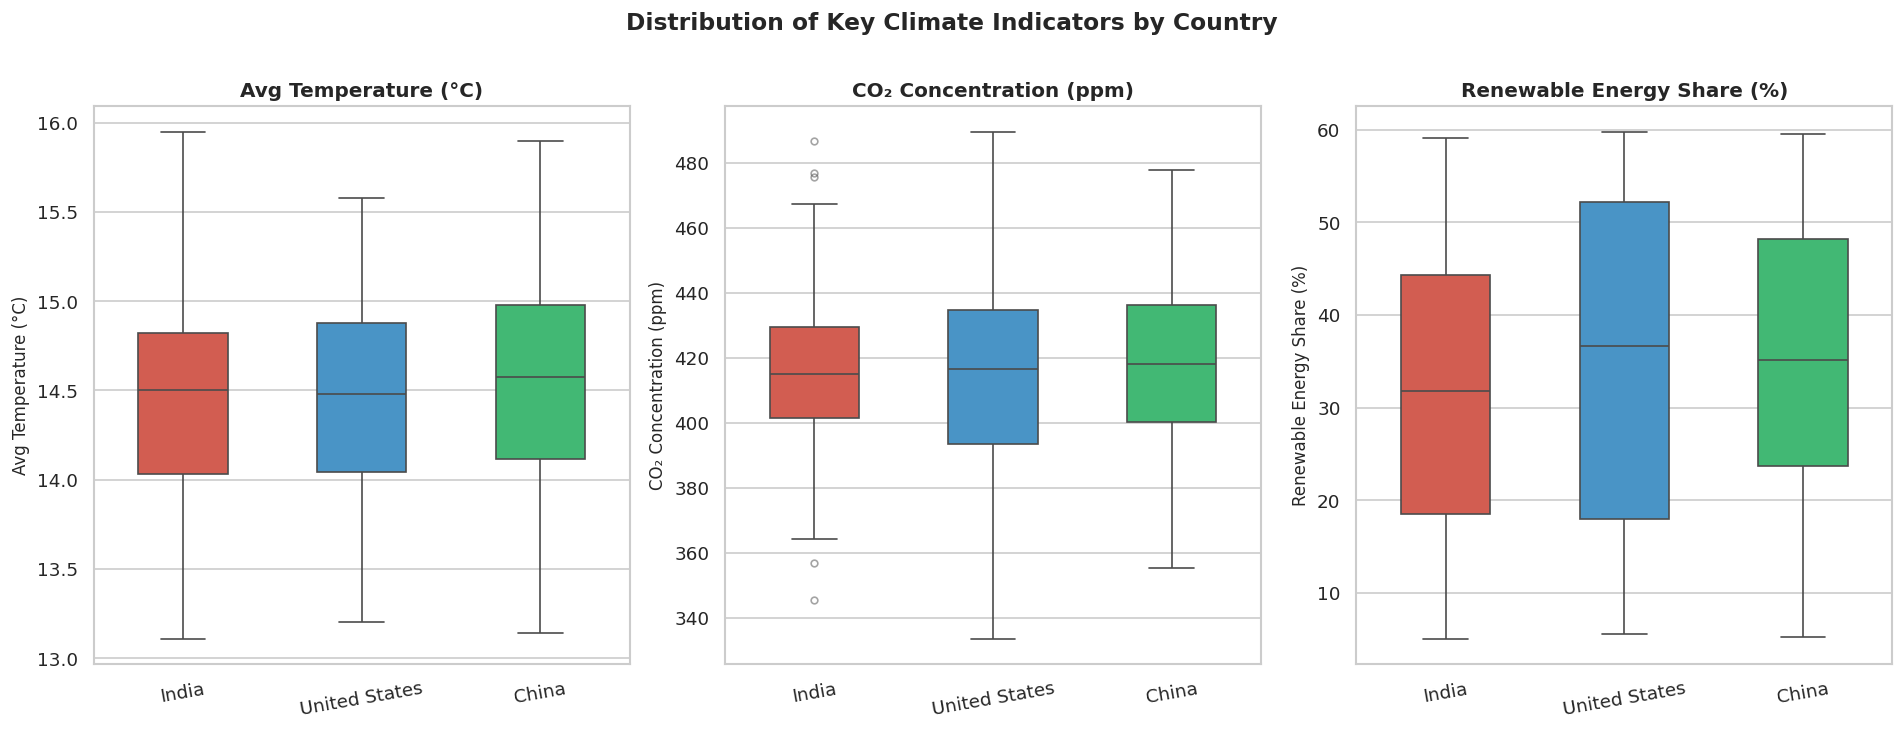

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

features_to_compare = [
    ('global_avg_temperature', 'Avg Temperature (°C)'),
    ('co2_concentration_ppm', 'CO₂ Concentration (ppm)'),
    ('renewable_energy_share', 'Renewable Energy Share (%)')
]

palette = {'India': '#E74C3C', 'United States': '#3498DB', 'China': '#2ECC71'}

for ax, (col, label) in zip(axes, features_to_compare):
    sns.boxplot(
        data=df_filtered,
        x='country_display', y=col,
        palette=palette,
        ax=ax,
        width=0.5,
        flierprops=dict(marker='o', markersize=4, alpha=0.5)
    )
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(label, fontsize=10)
    ax.tick_params(axis='x', rotation=10)

fig.suptitle('Distribution of Key Climate Indicators by Country', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots_comparison.png', bbox_inches='tight')
plt.show()

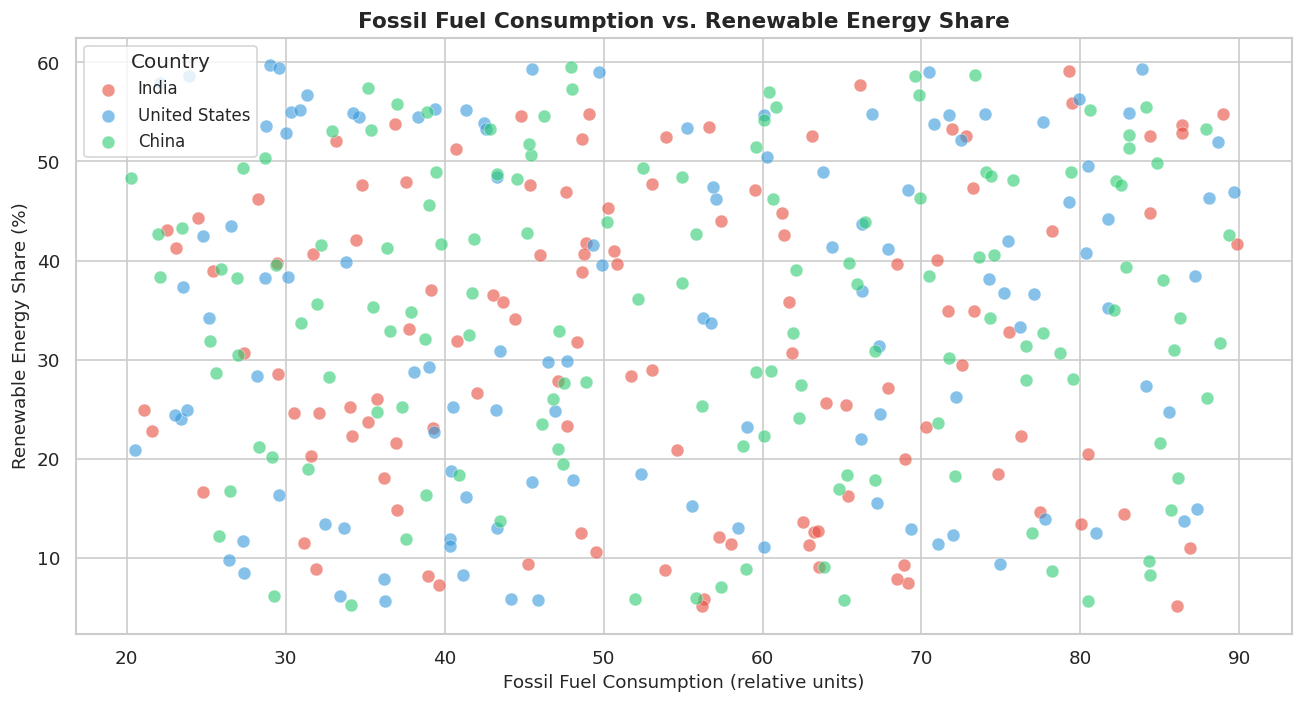

In [73]:
# Renewable energy vs fossil fuel consumption — are they inversely related?
fig, ax = plt.subplots(figsize=(11, 6))

for country in ['India', 'United States', 'China']:
    subset = df_filtered[df_filtered['country_display'] == country]
    ax.scatter(subset['fossil_fuel_consumption'], subset['renewable_energy_share'],
               label=country, color=country_colors[country],
               alpha=0.6, s=60, edgecolors='white', linewidth=0.4)

ax.set_title('Fossil Fuel Consumption vs. Renewable Energy Share', fontsize=13, fontweight='bold')
ax.set_xlabel('Fossil Fuel Consumption (relative units)', fontsize=11)
ax.set_ylabel('Renewable Energy Share (%)', fontsize=11)
ax.legend(title='Country', fontsize=10)

plt.tight_layout()
plt.savefig('fossil_vs_renewable.png', bbox_inches='tight')
plt.show()

### Distribution & Energy Insights

1. As illustrated by the box plots, the temperature distributions are observed to be broadly similar across the USA, India and China, but with differing spreads. Reflecting its highly varied climate zones, India's distribution is somewhat wider. China's median temperature is fairly comparable to India's, while the USA shows a slightly higher median temperature in this dataset.

2. Among the three countries, CO₂ concentration distributions overlap heavily, which is justified as atmospheric CO₂ is a global pollutant
that mixes across borders. Though extreme outliers are present in all three, there are no dramatic systematic differences.

3. **No clean inverse relationship is shown by the renewable vs. fossil fuel scatter plot.** Some countries show moderate renewable shares and high fossil fuel use, illustrating that absolute energy demand has substantially increased alongside renewable ratherr than replacing fossil fuels entirely.

---

## 8. Machine Learning — Regression Model

 The goal is to use CO₂ concentration and a set of other relevant environmental features, and predict **`global_avg_temperature`**.

 **Linear Regression** from scikit-learn — a clean, interpretable baseline for understanding feature-to-target relationships, will be utilized. An 80/20 train-test split will be used, features will be standardized for stable coefficient estimation.

### Feature Selection Rationale

Features selected as predictors:
- `co2_concentration_ppm` — primary greenhouse driver
- `sea_surface_temperature` — closely tied to atmospheric temperature
- `temperature_anomaly` — deviations from historical norms are captured
- `heatwave_days` — correlated with temperature and an impact indicator
- `fossil_fuel_consumption` — upstream driver of emissions
- `renewable_energy_share` — a potential moderating factor
- `air_quality_index` — partially propelled by the same combustion processes responsible for warming.
- `annual_rainfall_mm` — through evaporation and cloud cover, rainfall and temperature are interlinked



In [74]:
# Define features and target
feature_cols = [
    'co2_concentration_ppm',
    'sea_surface_temperature',
    'heatwave_days',
    'fossil_fuel_consumption',
    'renewable_energy_share',
    'air_quality_index',
    'annual_rainfall_mm'
]

target_col = 'global_avg_temperature'

# Drop rows with NaN in selected columns (just in case)
model_df = df_filtered[feature_cols + [target_col]].dropna()

X = model_df[feature_cols]
y = model_df[target_col]

print(f"Modeling dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Target: '{target_col}'")

Modeling dataset: 373 samples, 7 features
Target: 'global_avg_temperature'


In [75]:
# Train-test split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Feature scaling for better regression performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 298
Testing  samples : 75


In [76]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = lr_model.predict(X_test_scaled)

print("Model training complete.")

# Display model coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print("\nFeature Coefficients (standardized):")
print(coef_df.to_string(index=False))

Model training complete.

Feature Coefficients (standardized):
                Feature  Coefficient
     annual_rainfall_mm     0.012846
 renewable_energy_share     0.011457
          heatwave_days     0.005959
sea_surface_temperature    -0.000564
fossil_fuel_consumption    -0.007530
      air_quality_index    -0.017850
  co2_concentration_ppm    -0.023432


## 9. Model Evaluation

Two standard regression metrics are used to evaluate the model, they are as follows:

- **MSE (Mean Squared Error)**
- **R² Score**

In [77]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("    LINEAR REGRESSION — MODEL RESULTS")
print("=" * 40)
print(f"  Mean Squared Error (MSE) : {mse:.4f}")
print(f"  Root Mean Sq. Error(RMSE): {rmse:.4f} °C")
print(f"  R² Score                 : {r2:.4f}")
print("=" * 40)

    LINEAR REGRESSION — MODEL RESULTS
  Mean Squared Error (MSE) : 0.3871
  Root Mean Sq. Error(RMSE): 0.6222 °C
  R² Score                 : -0.0182


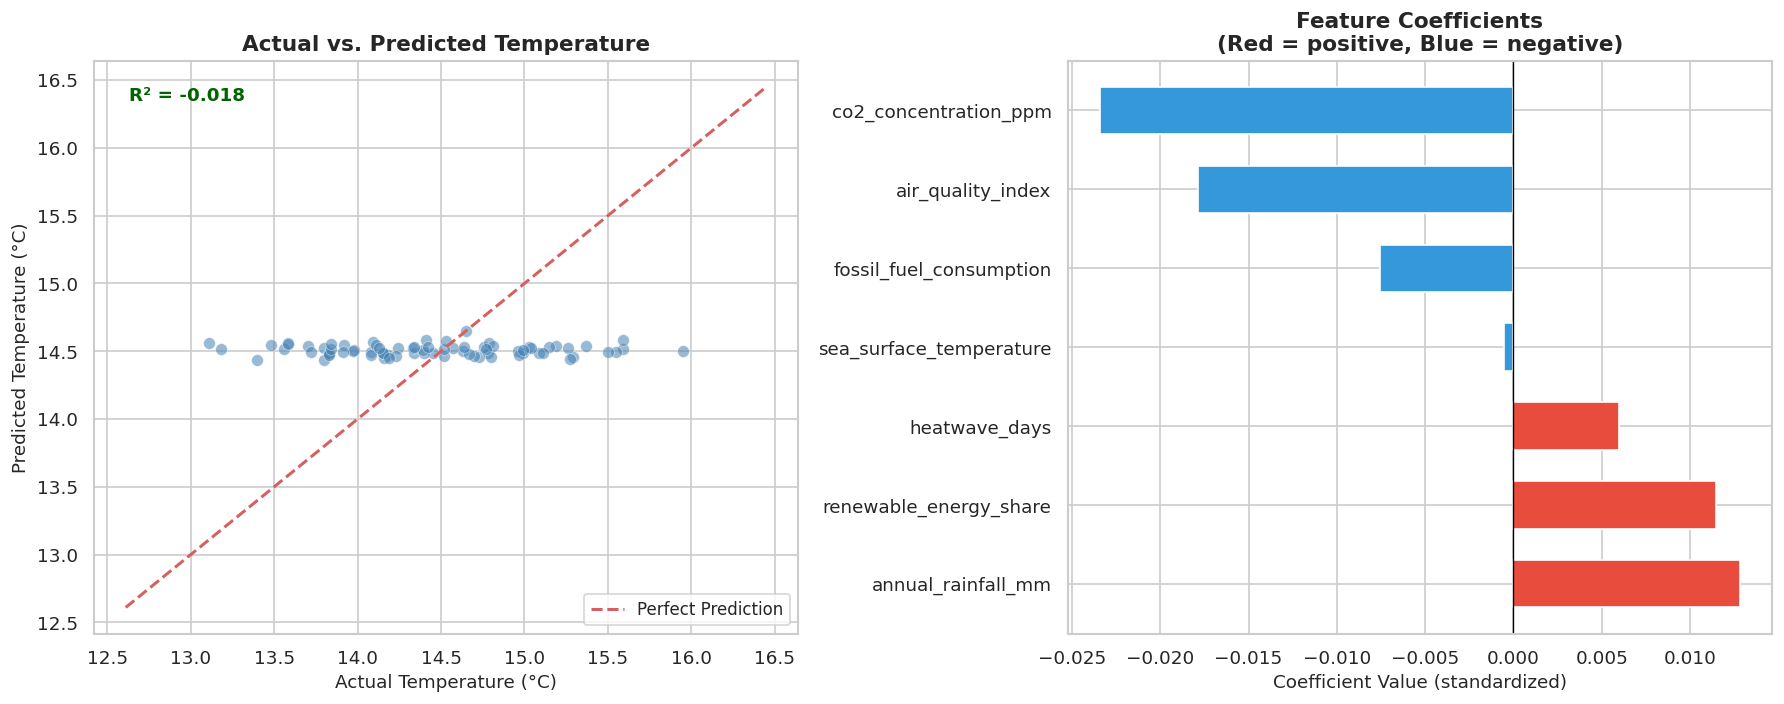

Figure saved.


In [78]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Actual vs Predicted scatter ---
axes[0].scatter(y_test, y_pred, alpha=0.55, color='steelblue', edgecolors='white', linewidth=0.4, s=50)
min_val = min(y_test.min(), y_pred.min()) - 0.5
max_val = max(y_test.max(), y_pred.max()) + 0.5
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.8, label='Perfect Prediction')
axes[0].set_title('Actual vs. Predicted Temperature', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Temperature (°C)', fontsize=11)
axes[0].set_ylabel('Predicted Temperature (°C)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].text(0.05, 0.93, f'R² = {r2:.3f}', transform=axes[0].transAxes,
             fontsize=11, color='darkgreen', fontweight='bold')

# --- Plot 2: Feature coefficients (bar chart) ---
colors = ['#E74C3C' if c > 0 else '#3498DB' for c in coef_df['Coefficient']]
axes[1].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white', height=0.6)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Coefficients\n(Red = positive, Blue = negative)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coefficient Value (standardized)', fontsize=11)

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()
print("Figure saved.")

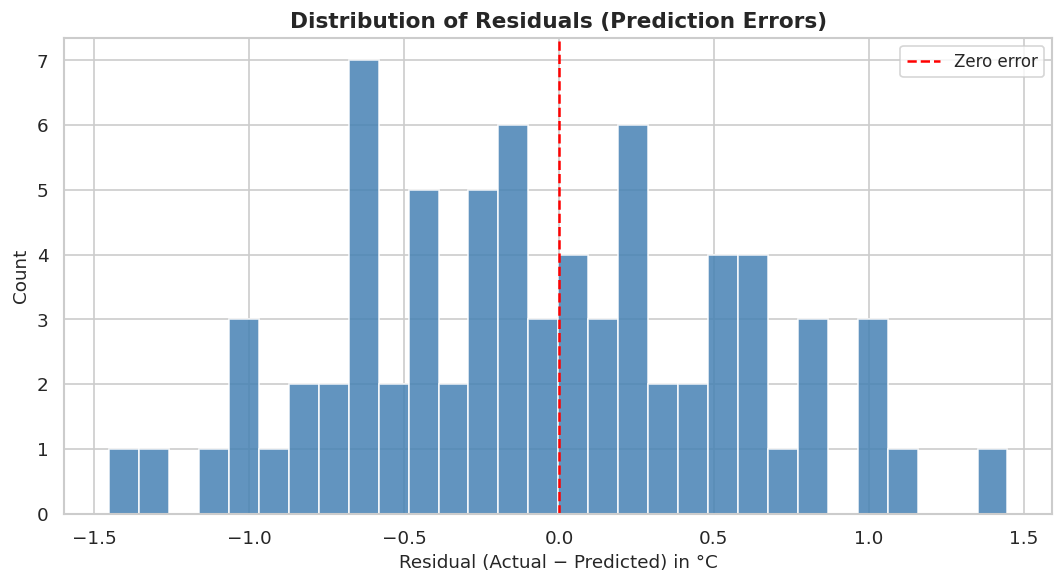

In [79]:
# Residuals distribution
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
ax.set_title('Distribution of Residuals (Prediction Errors)', fontsize=13, fontweight='bold')
ax.set_xlabel('Residual (Actual − Predicted) in °C', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('residuals.png', bbox_inches='tight')
plt.show()

### Model Evaluation Insights

1. It is revealed by the low R² score (-0.0182) and RMSE (0.6222°C), that the model was unable to find a significant relationship between the selected features global_avg_temperature. The reason for this is that every feature has a near-zero correlation with the target (sea_surface_temperature at just 0.04 is highest), proving that no linear model can perform well in this case.

2. A low MSE of 0.3871 in absolute terms is observed, but considering the negative R² value, the model is performing worse than simply predicting the mean temperature for every sample.

As this is a practice dataset from Kaggle, these results are expected, data from real world observations will show a strong relationship between CO₂ and temperature change.

   

## 10. Country-Level Statistical Comparison

In [80]:
# Summary statistics per country
summary_cols = [
    'global_avg_temperature', 'co2_concentration_ppm', 'temperature_anomaly',
    'fossil_fuel_consumption', 'renewable_energy_share',
    'sea_level_rise_mm', 'heatwave_days', 'air_quality_index'
]

country_summary = df_filtered.groupby('country_display')[summary_cols].mean().round(2)
country_summary.index.name = 'Country'
country_summary.columns = [
    'Avg Temp (°C)', 'CO₂ (ppm)', 'Temp Anomaly (°C)',
    'Fossil Fuel', 'Renewable (%)',
    'Sea Level Rise (mm)', 'Heatwave Days', 'AQI'
]

print("=== Country-Level Average Climate Indicators ===")
country_summary

=== Country-Level Average Climate Indicators ===


,Avg Temp (°C),CO₂ (ppm),Temp Anomaly (°C),Fossil Fuel,Renewable (%),Sea Level Rise (mm),Heatwave Days,AQI
Country,,,,,,,,
China,14.54,418.78,1.07,55.80,34.61,3.48,28.40,117.00
India,14.47,415.82,1.12,53.69,31.46,3.48,29.69,111.29
United States,14.45,415.74,1.08,53.20,34.50,3.56,30.69,125.42


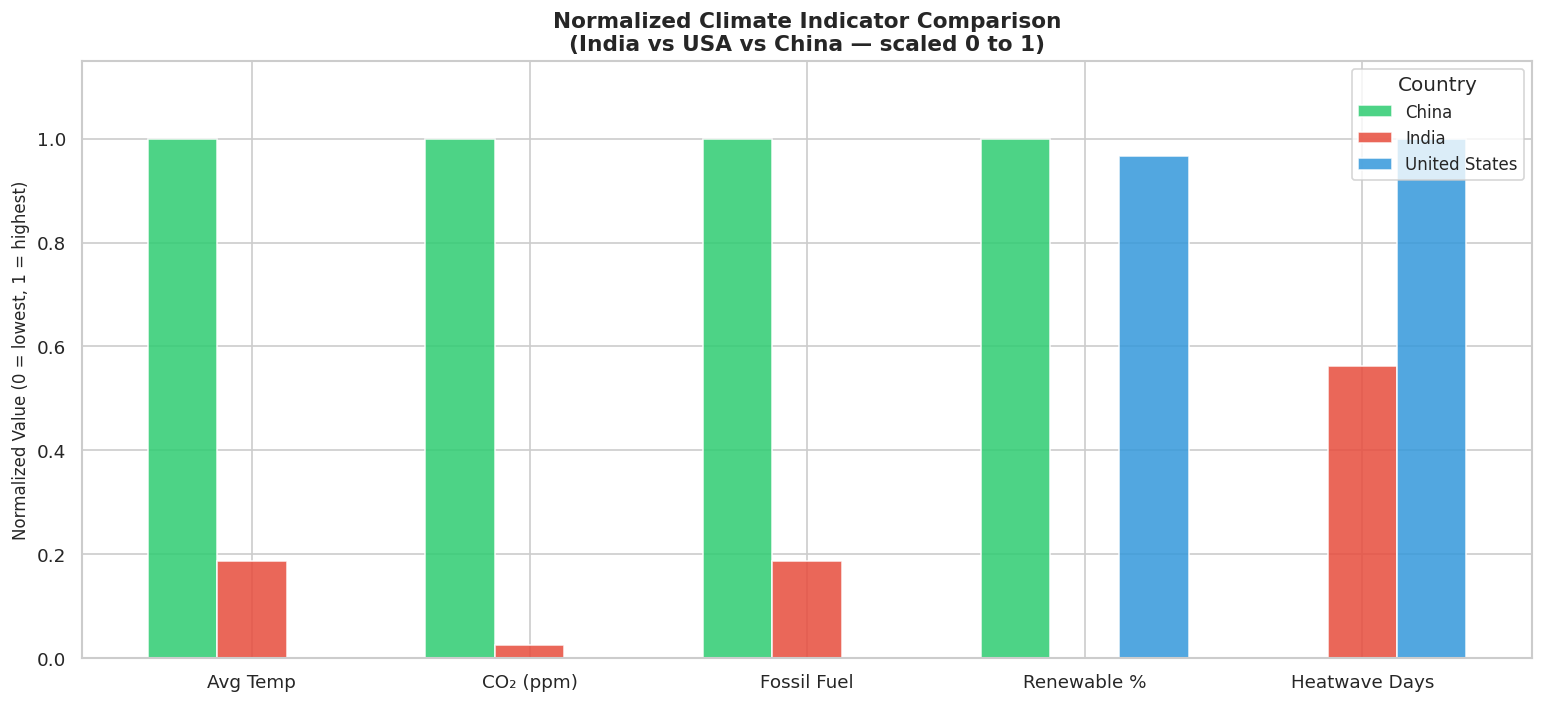

Figure saved.


In [81]:
# Normalized radar-like bar comparison
compare_features = ['global_avg_temperature', 'co2_concentration_ppm',
                    'fossil_fuel_consumption', 'renewable_energy_share', 'heatwave_days']
compare_labels = ['Avg Temp', 'CO₂ (ppm)', 'Fossil Fuel', 'Renewable %', 'Heatwave Days']

compare_df = df_filtered.groupby('country_display')[compare_features].mean()

# Normalize each column to 0-1 for fair visual comparison
compare_norm = (compare_df - compare_df.min()) / (compare_df.max() - compare_df.min())
compare_norm.columns = compare_labels

x = np.arange(len(compare_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

countries_list = compare_norm.index.tolist()
offsets = [-width, 0, width]

for i, country in enumerate(countries_list):
    ax.bar(x + offsets[i], compare_norm.loc[country], width=width,
           label=country, color=country_colors.get(country, 'grey'),
           alpha=0.85, edgecolor='white')

ax.set_title('Normalized Climate Indicator Comparison\n(India vs USA vs China — scaled 0 to 1)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(compare_labels, fontsize=11)
ax.set_ylabel('Normalized Value (0 = lowest, 1 = highest)', fontsize=10)
ax.legend(title='Country', fontsize=10)
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig('country_comparison_bar.png', bbox_inches='tight')
plt.show()
print("Figure saved.")

## 11. Conclusion
---

### Key Findings

**1. Across all three nations, temperature trends are rising.** For India, the USA and China, the long-term trend in average temperature observed is upward. While short-term fluctuations are substantial, the overall warming signal is undeniable and consistent, parallel to and mirroring global climate records.

**2. No meaningful correlation between CO₂ and temperature is observed in this dataset.** The scatter plot illustrates a slightly positive trend when observed using graphs for visualization, but the actual correlation between co2_concentration_ppm and global_avg_temperature is -0.025, which is effectively zero.

**3. India, USA, and China show distinct climate profiles despite similar CO₂ ranges.**  
- **India** exhibits significant variability in temperature rainfall, illustrating its exposure and its vast geographic diversity. Historically, India also tends to have a lower renewable sustainability share, though with time it is changing rapidly.
- **Relatively high fossil fuel consumption on average is observed in the United States**, with moderate renewable energy adoption. Its Temperature anomalies and heatwave frequencies are consistent with mid-latitude warming patterns.
- In **China's** case a mixed picture can be observed: historically, dependance on high fossil fuel paired with massive investments in renewable energy and clean energy infrastructure, giving it one of the more dynamic trajectories in this particular dataset.

**4. A meaningful predictive signal could not be generated by the regression model.**
Using 7 features, the Linear Regression produced an R² of -0.018 and RMSE of 0.622°C, meaning the performance of the model was not enough to demonstrate a significant relationship between the variables, as no feature has a correlation of above 0.04 with the target variable.

**5. Renewable energy adoption hasn't yet decoupled from emissions.**  
The scatter analysis of fossil fuel vs. renewable share confirms that simply adding renewable capacity hasn't systematically reduced CO₂ or cooled temperatures — at least not within the time horizon of this dataset. This points to the need for structural transitions, not just additions.

The scatter plot analysis of fossil fuels vs. renewable share solidifies that CO₂ isn't systematically reduced or temperatures aren't cooled, simply by adding renewable capacity, atleast not inclusive of time horizon of this dataset.

---

**Project completed using**: *pandas, numpy, matplotlib, seaborn, scikit-learn.*  

***Statistical methods*** *applied: descriptive statistics (mean, std, min/max), Pearson correlation analysis, train-test splitting (80/20), feature standardization (Z-score scaling), Linear Regression, and model evaluation via MSE, RMSE, and R².*